# Gaussian Naive Bayes for Diabetes Prediction

## Project

Pima Indians Diabetes Classification

## Objective

The objective of this notebook is to train and evaluate a Gaussian Naive Bayes classifier on the Pima Indians Diabetes Dataset and compare its performance with Logistic Regression.

---

## Dataset

Pima Indians Diabetes Dataset

---

## Workflow

1. Import libraries
2. Load dataset
3. Inspect the data
4. Prepare features and target
5. Split the dataset
6. Train Gaussian Naive Bayes Model
7. Make predictions
8. Evaluate performance
9. Interpret results
10. Compare with Logistic Regression

## IMPORT LIBRARIES
In this section, we import the libraries required for data manipulation,
model training, evaluation, and visualization.

In [1]:
## Data Manipulation
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

## LOAD DATASET
In this section, we load the Pima Indians Diabetes Dataset into a pandas DataFrame so that it can be inspected and prepared for machine learning.

In [2]:
df = pd.read_csv("../data/diabetes.csv")

In [3]:
## Display the first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Display the dimensions of the dataset
df.shape

(768, 9)

In [5]:
# Display the information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Display summary statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## PREPARE FEATURES AND TARGET

Machine learning models require the dataset to be separated into:

- **Features (X):** the predictor variables used to make predictions.
- **Target (y):** the variable the model is trying to predict.

In [7]:
# Features
X = df.drop("Outcome", axis=1) # axis=1 tell pandas to remove a column, 0 tells it to remove a row
# Target 
y = df["Outcome"]

## SPLIT THE DATA SET INTO TRAINING AND TEST DATA
To evaluate how well our model generalizes to unseen data, we split the dataset into training and testing sets.

- **80%** of the data is used for training.
- **20%** is reserved for testing.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


## TRAINING THE GAUSSIAN NAIVE BAYES MODEL
In this section, we create a Gaussian Naive Bayes classifier and train it using the training data.

The model learns patterns from the predictor variables (features) to predict whether the patient has diabetes


In [9]:
model = GaussianNB()
model.fit(X_train, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[401.,213.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.349e-05
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[ 3.24,110.21, 68.31,..., 30.26, 0.43, 30.56], [ 4.69,140.89, 71.5 ,..., 35.23, 0.54, 37.33]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[ 9.14, 676.64, 311.27,..., 56.69, 0.09, 122.53], [ 13.03,1065.16, 393.68,..., 49.52, 0.14, 120.16]]"


## MAKE PREDICTIONS
After training the model, we use it to predict the outcomes for the unseen test dataset.

In [10]:
y_pred = model.predict(X_test)

## EVALUATE THE TRAINED MODEL

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Training accuracy: {accuracy:.2f}")

# Evaluating Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix: {cm}")

Training accuracy: 0.77
Confusion Matrix: [[79 20]
 [16 39]]


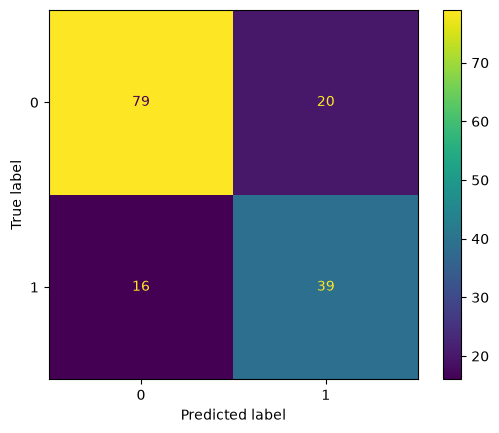

In [12]:
# Visualizing the Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Interpretation of the Confusion Matrix

The confusion matrix provides a detailed breakdown of the model's predictions by comparing the predicted class with the actual class.

The four possible outcomes are:

- **True Negative (TN):** The model correctly predicts that a patient does not have diabetes.
- **False Positive (FP):** The model predicts that a patient has diabetes when they do not.
- **False Negative (FN):** The model predicts that a patient does not have diabetes when they actually do.
- **True Positive (TP):** The model correctly predicts that a patient has diabetes.

### Importance in Healthcare

In a healthcare setting, **False Negatives are often the most critical errors**. A false negative means a patient who actually has diabetes is classified as healthy. This could delay diagnosis, treatment, and lifestyle interventions, potentially leading to complications.

False Positives are also undesirable because they may lead to unnecessary follow-up tests and anxiety for patients. However, in many screening scenarios, healthcare professionals prefer to investigate a false alarm rather than miss a patient who truly has the disease.

Therefore, while overall accuracy is important, the confusion matrix helps us understand the types of mistakes the model makes and whether those mistakes are acceptable for the intended application.

In [13]:
# Classification report: which gives us Precision, Recall, F1-Score and Support
class_report = classification_report(y_test, y_pred)
print(f"The classification report: {class_report}")

The classification report:               precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [14]:
#ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")

ROC-AUC Score: 0.83


In [1]:
# Plotting the ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label= f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Flase Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gaussian Naive Bayes")
plt.legend()
plt.show()

NameError: name 'roc_curve' is not defined

## Conclusion

A Gaussian Naive Bayes classifier was trained on the Pima Indians Diabetes Dataset to predict whether a patient has diabetes.

The model achieved:

- Accuracy: **77%**
- ROC-AUC Score: **0.83**

These results indicate that the model has good discriminative ability and performed slightly better than the Logistic Regression model previously evaluated on the same dataset.

Although Gaussian Naive Bayes assumes that features are conditionally independent and normally distributed within each class, it still produced competitive performance on this healthcare dataset.

Future work will compare this model with Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM) classifiers.
